In [27]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.2f}".format

print("Imports OK.")


Imports OK.


EDA. checking the mulitple angles!

In [30]:
df_final_clean = pd.read_pickle('FINAL_CLEAN_DATASET_2015_2026.pkl') # pickle file name

df_final_clean['US$ FOB'] = pd.to_numeric(df_final_clean['US$ FOB'], errors='coerce')

# total FOB value and transaction count per year
eda_overview = df_final_clean.groupby('ANO').agg({
    'US$ FOB': ['sum', 'mean', 'count'],
    'RUC IMPORTADOR': 'nunique'
})

# renaming columns for clarity
eda_overview.columns = ['Total_FOB', 'Avg_Transaction_Value', 'Num_Transactions', 'Unique_Importers']
print(eda_overview)

          Total_FOB  Avg_Transaction_Value  Num_Transactions  Unique_Importers
ANO                                                                           
2015 642,555,436.27              48,088.27             13362               418
2016 525,808,934.13              39,788.80             13215               411
2017 552,724,752.91              41,155.98             13430               518
2018 641,705,436.84              46,102.84             13919               540
2019 671,594,182.69              54,038.80             12428               594
2020 517,538,191.52              47,884.73             10808               728
2021 856,444,760.40              52,994.54             16161               965
2022 509,177,203.86              40,311.71             12631               731
2023 650,799,755.85              64,352.79             10113               765
2024 721,761,699.09              55,652.84             12969               888
2025 905,350,566.69              62,086.86          

### Year-over-Year Growth Rates

,Total_FOB,YoY_FOB_Growth_Pct,Num_Transactions,YoY_Volume_Growth_Pct,Unique_Importers,YoY_Importer_Growth_Pct
ANO,,,,,,
2015,"642,555,436.27",NaN,13362,NaN,418,NaN
2016,"525,808,934.13",-18.17,13215,-1.10,411,-1.67
2017,"552,724,752.91",5.12,13430,1.63,518,26.03
2018,"641,705,436.84",16.10,13919,3.64,540,4.25
2019,"671,594,182.69",4.66,12428,-10.71,594,10.00
2020,"517,538,191.52",-22.94,10808,-13.04,728,22.56
2021,"856,444,760.40",65.48,16161,49.53,965,32.55
2022,"509,177,203.86",-40.55,12631,-21.84,731,-24.25
2023,"650,799,755.85",27.81,10113,-19.94,765,4.65


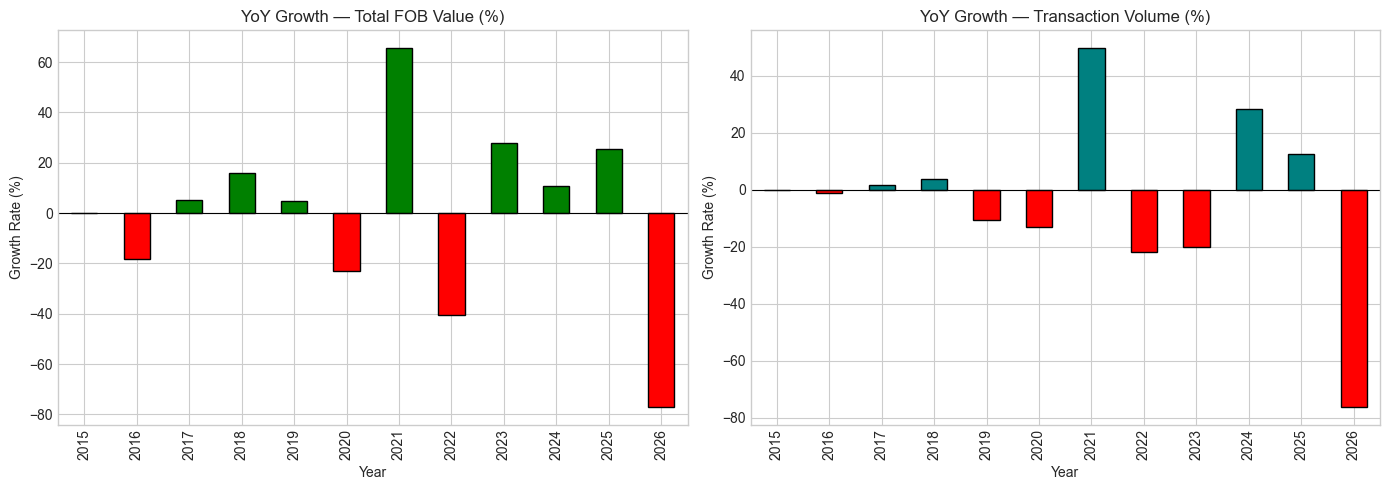

In [33]:
# YoY growth in FOB value, transaction volume, and unique importers
eda_overview['YoY_FOB_Growth_Pct']        = eda_overview['Total_FOB'].pct_change() * 100
eda_overview['YoY_Volume_Growth_Pct']     = eda_overview['Num_Transactions'].pct_change() * 100
eda_overview['YoY_Importer_Growth_Pct']   = eda_overview['Unique_Importers'].pct_change() * 100

display(eda_overview[[
    'Total_FOB', 'YoY_FOB_Growth_Pct',
    'Num_Transactions', 'YoY_Volume_Growth_Pct',
    'Unique_Importers', 'YoY_Importer_Growth_Pct'
]])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_fob = ['red' if x < 0 else 'green' for x in eda_overview['YoY_FOB_Growth_Pct']]
eda_overview['YoY_FOB_Growth_Pct'].plot(
    kind='bar', ax=axes[0], color=colors_fob, edgecolor='black')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title('YoY Growth — Total FOB Value (%)')
axes[0].set_ylabel('Growth Rate (%)')
axes[0].set_xlabel('Year')

colors_vol = ['red' if x < 0 else 'teal' for x in eda_overview['YoY_Volume_Growth_Pct']]
eda_overview['YoY_Volume_Growth_Pct'].plot(
    kind='bar', ax=axes[1], color=colors_vol, edgecolor='black')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('YoY Growth — Transaction Volume (%)')
axes[1].set_ylabel('Growth Rate (%)')
axes[1].set_xlabel('Year')

plt.tight_layout()
plt.savefig('2_yoy_growth.png', dpi=150, bbox_inches='tight')
plt.show()


--- Top 10 Importers by Market Share ---
IMPORTADOR
FERREYROS SOCIEDAD AN?NIMA             25.70
VOLVO PERU S A                          9.34
KOMATSU-MITSUI MAQUINARIAS PERU S.A.    5.16
DIVEIMPORT S.A.                         4.88
IPESA S.A.C.                            4.13
ATLAS COPCO PERUANA S A                 3.73
SANDVIK DEL PERU S A                    3.58
UNIMAQ S.A.                             3.18
SOCIEDAD MINERA CERRO VERDE S.A.A.      3.06
SCANIA DEL PERU S A                     2.57
Name: US$ FOB, dtype: float64


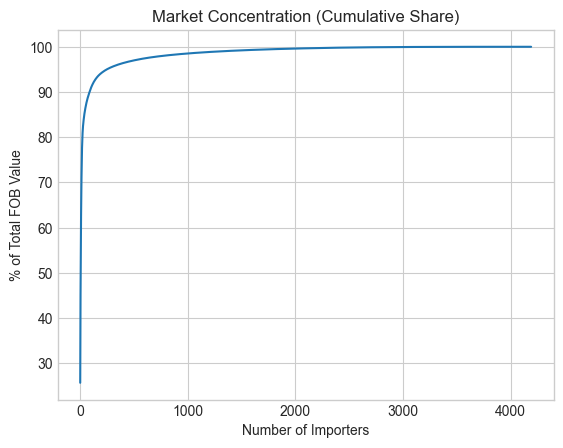

In [35]:
# market share per importer for the whole period
importer_shares = df_final_clean.groupby('IMPORTADOR')['US$ FOB'].sum().sort_values(ascending=False)
total_market_fob = importer_shares.sum()
importer_pct_share = (importer_shares / total_market_fob) * 100

print("--- Top 10 Importers by Market Share ---")
print(importer_pct_share.head(10))

# Lorenz Curve / Cumulative Share
cumulative_share = importer_pct_share.cumsum()
plt.plot(range(len(cumulative_share)), cumulative_share.values)
plt.title('Market Concentration (Cumulative Share)')
plt.xlabel('Number of Importers')
plt.ylabel('% of Total FOB Value')
plt.grid(True)
plt.savefig('2_market_concentration.png', dpi=150, bbox_inches='tight')
plt.show()

### Market Concentration Metrics — Gini & HHI

Corrected Gini Coefficient: 0.9720
  → 0 = perfect equality  |  1 = one company controls everything

Herfindahl-Hirschman Index (HHI): 892.6
  → <1500 = unconcentrated  |  1500-2500 = moderate  |  >2500 = highly concentrated
  → Classification: UNCONCENTRATED MARKET


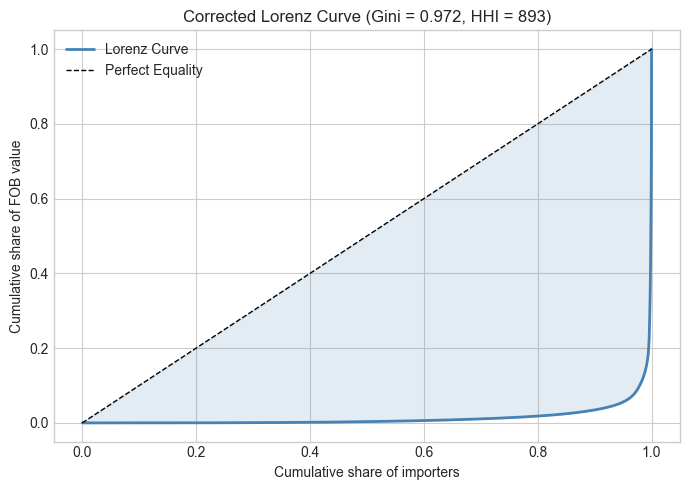

In [38]:

# ── Gini Coefficient ────────────────────────────────────────────────────────
importer_pct_share_sorted = importer_pct_share.sort_values(ascending=True)

# calculate cumulative shares normalized to 1
_shares_arr = np.concatenate([[0], importer_pct_share_sorted.cumsum().values / 100])
_n = len(_shares_arr)

# Calculate x-axis points from 0 to 1
lorenz_x = np.linspace(0, 1, _n)

# Gini Formula: 1 - 2 * (Area under the Lorenz Curve)
# Using np.trapezoid for NumPy 2.0 compatibility
gini = 1 - 2 * np.trapezoid(_shares_arr, lorenz_x)

print(f"Corrected Gini Coefficient: {gini:.4f}")
print("  → 0 = perfect equality  |  1 = one company controls everything")

# ── Herfindahl-Hirschman Index (HHI) ────────────────────────────────────────
# HHI is calculated on the original shares
hhi = (importer_pct_share ** 2).sum()

print(f"\nHerfindahl-Hirschman Index (HHI): {hhi:.1f}")
print("  → <1500 = unconcentrated  |  1500-2500 = moderate  |  >2500 = highly concentrated")

if hhi < 1500:
    print("  → Classification: UNCONCENTRATED MARKET")
elif hhi < 2500:
    print("  → Classification: MODERATELY CONCENTRATED MARKET")
else:
    print("  → Classification: HIGHLY CONCENTRATED MARKET")

# ── Visual: Lorenz + 45° equality line ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(lorenz_x, _shares_arr, color='steelblue', lw=2, label='Lorenz Curve')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect Equality')

# Shade the area representing the Gini coefficient
ax.fill_between(lorenz_x, lorenz_x, _shares_arr, alpha=0.15, color='steelblue')

ax.set_title(f'Corrected Lorenz Curve (Gini = {gini:.3f}, HHI = {hhi:.0f})')
ax.set_xlabel('Cumulative share of importers')
ax.set_ylabel('Cumulative share of FOB value')
ax.legend()
plt.tight_layout()
plt.savefig('2_lorenz_gini_curve.png', dpi=150, bbox_inches='tight')
plt.show()


### EDA: Used Machinery Market

RFM ANALYSIS

In [42]:
# we need to make sure AÑO is numeric
df_final_clean['ANO'] = df_final_clean['ANO'].astype(int)

rfm = df_final_clean.groupby(['RUC IMPORTADOR', 'IMPORTADOR']).agg({
    'ANO': 'max',            # Recency (Last year active)
    'PARTIDA_CLEAN': 'count', # Frequency (Total transactions)
    'US$ FOB': 'sum'          # Monetary (Total Value)
}).rename(columns={
    'ANO': 'Last_Active',
    'PARTIDA_CLEAN': 'Frequency',
    'US$ FOB': 'Monetary'
})

# "Recency Score" (Years since last active)
current_year = 2026 # Based on current date
rfm['Years_Since_Active'] = current_year - rfm['Last_Active']

print(rfm.sort_values('Monetary', ascending=False).head(10))

                                                     Last_Active  Frequency  \
RUC IMPORTADOR IMPORTADOR                                                     
20100028698    FERREYROS SOCIEDAD AN?NIMA                   2026      73427   
20100070031    VOLVO PERU S A                               2026       6332   
20302241598    KOMATSU-MITSUI MAQUINARIAS PERU S.A.         2026       2187   
20502797230    DIVEIMPORT S.A.                              2021       4423   
20101639275    IPESA S.A.C.                                 2026       1963   
20100082803    ATLAS COPCO PERUANA S A                      2026        523   
20100134706    SANDVIK DEL PERU S A                         2026        630   
20100027021    UNIMAQ S.A.                                  2026       5234   
20170072465    SOCIEDAD MINERA CERRO VERDE S.A.A.           2026        134   
20101363008    SCANIA DEL PERU S A                          2021       1988   

                                                   

In [44]:
# Group by 'RUC IMPORTADOR' and count unique 'IMPORTADOR' names
ruc_name_counts = df_final_clean.groupby('RUC IMPORTADOR')['IMPORTADOR'].nunique()

# Filter for RUCs that have more than one unique 'IMPORTADOR' name
inconsistent_rucs = ruc_name_counts[ruc_name_counts > 1].index

# Display the RUCs and their associated unique 'IMPORTADOR' names
print("RUCs with inconsistent 'IMPORTADOR' names:")
for ruc in inconsistent_rucs:
    names = df_final_clean[df_final_clean['RUC IMPORTADOR'] == ruc]['IMPORTADOR'].unique()
    print(f"RUC: {ruc}, Names: {list(names)}")

RUCs with inconsistent 'IMPORTADOR' names:


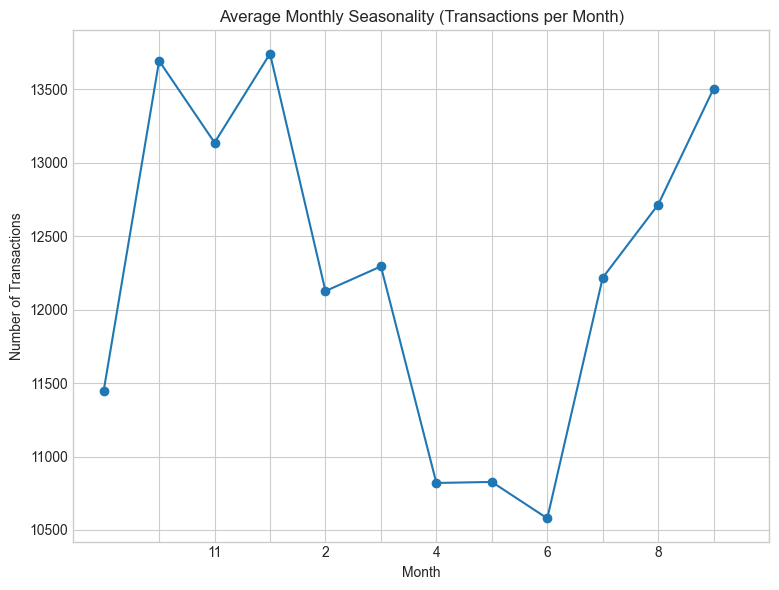

In [46]:
# Monthly seasonality across all years
monthly_trend = df_final_clean.groupby('MES').size()

# Yearly seasonality across all years
yearly_trend = df_final_clean.groupby('ANO').size()

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
monthly_trend.plot(kind='line', marker='o', title='Average Monthly Seasonality (Transactions per Month)')
plt.xticks(range(1, 13))
plt.xlabel('Month')
plt.ylabel('Number of Transactions')


plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.savefig('2_month_season.png', dpi=150, bbox_inches='tight')
plt.show()

THERE ARE MULTIPLE DOUBLE ENTRIES DUE TO COMPANIES BEING DIFFERENTLY NAMED/RECORDED. Le'ts focus on the RUC number instead

In [51]:
# 1. Create a "Master Name Map"
# We take the most frequent name used for each RUC so we get the 'cleanest' version
name_map = (
    df_final_clean.groupby('RUC IMPORTADOR')['IMPORTADOR']
    .agg(lambda x: x.value_counts().index[0] if not x.value_counts().empty else None) # Picks the most common name, handles empty groups
    .to_dict()
)

# 2. Apply the Master Name to the whole dataset
# Corrected 'RUC' to 'RUC IMPORTADOR' to match the map keys
df_final_clean['IMPORTADOR_CLEAN'] = df_final_clean['RUC IMPORTADOR'].map(name_map)

# 3. Recalculate RFM using the RUC as the unique ID
# Corrected 'RUC' to 'RUC IMPORTADOR' for grouping
rfm_unified = df_final_clean.groupby('RUC IMPORTADOR').agg({
    'IMPORTADOR_CLEAN': 'first', # Keep the clean name
    'ANO': 'max',                # Recency
    'PARTIDA_CLEAN': 'count',    # Frequency
    'US$ FOB': 'sum'             # Monetary
}).rename(columns={
    'IMPORTADOR_CLEAN': 'IMPORTADOR',
    'ANO': 'Last_Active',
    'PARTIDA_CLEAN': 'Frequency',
    'US$ FOB': 'Monetary'
})

# 4. Calculate Years Since Active
rfm_unified['Years_Since_Active'] = 2026 - rfm_unified['Last_Active']

# Sort by Monetary to see the "Kings of the Hill"
rfm_unified = rfm_unified.sort_values('Monetary', ascending=False)

# Display without scientific notation for your thesis check
pd.options.display.float_format = '{:,.2f}'.format
print(rfm_unified.head(10))

                                          IMPORTADOR  Last_Active  Frequency  \
RUC IMPORTADOR                                                                 
20100028698               FERREYROS SOCIEDAD AN?NIMA         2026      73427   
20100070031                           VOLVO PERU S A         2026       6332   
20302241598     KOMATSU-MITSUI MAQUINARIAS PERU S.A.         2026       2187   
20502797230                          DIVEIMPORT S.A.         2021       4423   
20101639275                             IPESA S.A.C.         2026       1963   
20100082803                  ATLAS COPCO PERUANA S A         2026        523   
20100134706                     SANDVIK DEL PERU S A         2026        630   
20100027021                              UNIMAQ S.A.         2026       5234   
20170072465       SOCIEDAD MINERA CERRO VERDE S.A.A.         2026        134   
20101363008                      SCANIA DEL PERU S A         2021       1988   

                       Monetary  Years_

### Importer Geography — Where Do Buyers Come From?

--- Import Activity by Department ---


,Total_FOB,Unique_Importers,Transactions,FOB_Share_Pct
DEPARTAMENTO DE IMPORTADOR,,,,
LIMA,"5,897,698,870.22",731,117544,79.65
UNKNOWN,"948,010,406.95",3125,22038,12.80
AREQUIPA,"238,891,230.87",77,662,3.23
LORETO,"162,838,214.29",8,2463,2.20
PROV. CONST. DEL CALLAO,"68,164,784.09",56,1043,0.92
PUNO,"25,264,926.09",36,464,0.34
CUSCO,"11,792,326.45",27,196,0.16
LA LIBERTAD,"8,274,885.61",25,1711,0.11
AMAZONAS,"7,911,789.91",6,92,0.11


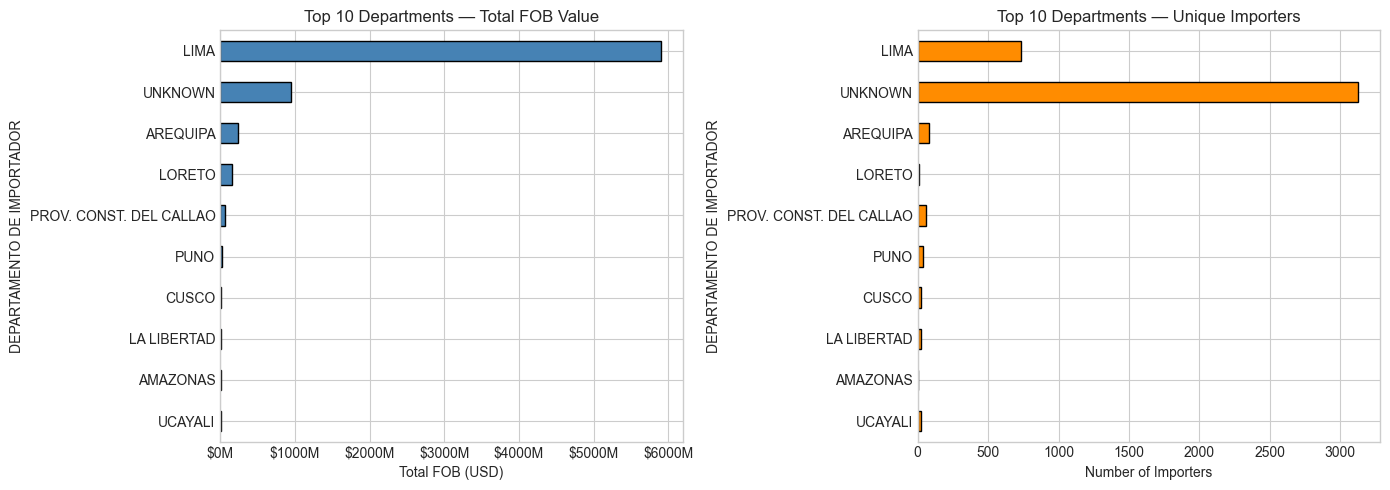

In [99]:
# Geographic distribution of importers by Peruvian department
dept = (
    df_final_clean
    .groupby('DEPARTAMENTO DE IMPORTADOR')
    .agg(
        Total_FOB=('US$ FOB', 'sum'),
        Unique_Importers=('RUC IMPORTADOR', 'nunique'),
        Transactions=('RUC IMPORTADOR', 'count')
    )
    .sort_values('Total_FOB', ascending=False)
)
dept['FOB_Share_Pct'] = (dept['Total_FOB'] / dept['Total_FOB'].sum()) * 100

print("--- Import Activity by Department ---")
display(dept.head(15))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top10 = dept.head(10)
top10['Total_FOB'].plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].invert_yaxis()
axes[0].set_title('Top 10 Departments — Total FOB Value')
axes[0].set_xlabel('Total FOB (USD)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))

top10['Unique_Importers'].plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].invert_yaxis()
axes[1].set_title('Top 10 Departments — Unique Importers')
axes[1].set_xlabel('Number of Importers')

plt.tight_layout()
plt.savefig('2_department.png', dpi=150, bbox_inches='tight')
plt.show()


FILTERING TO USED MACHINERY. NOT NEWWW

In [57]:
# 1. Standardize the 'ESTADO DE MERCANCIA' column
# We strip spaces and force uppercase to ensure the filter catches everything
df_final_clean['ESTADO DE MERCANCIA'] = (
    df_final_clean['ESTADO DE MERCANCIA']
    .astype(str)
    .str.upper()
    .str.strip()
)

# 2. Define the exclusion list
# We remove 'NUEVO', 'NUEVO DESARMADO', and 'NUEVA' (for feminine variations)
exclude_list = ['NUEVO', 'NUEVO DESARMADO', 'NUEVA', 'NUEVO SEMIARMADO', 'NUEVO RECONSTRUIDO', 'OTROS', 'NUEVO ARMADO', 'NUEVO AVERIADO', 'N', 'UNKNOWN', 'USADO SINIESTRADO', 'USADO AVERIADO' ]

# 3. Create the 'Used-Only' Dataset
# The ~ symbol means "NOT" in pandas
df_used_market = df_final_clean[~df_final_clean['ESTADO DE MERCANCIA'].isin(exclude_list)].copy()

# 4. Sanity Check
print("--- Remaining Product States ---")
print(df_used_market['ESTADO DE MERCANCIA'].value_counts())

print("\n--- Rows Comparison ---")
print(f"Original entries: {len(df_final_clean):,}")
print(f"Used Market entries: {len(df_used_market):,}")
print(f"Reduction: {((len(df_final_clean) - len(df_used_market)) / len(df_final_clean)) * 100:.2f}%")

# 5. Save this as your specific Business Target dataset
df_used_market.to_pickle("USED_MACHINERY_PERU_2015_2026.pkl")

--- Remaining Product States ---
ESTADO DE MERCANCIA
USADO                    8836
USADO DESARMADO          1136
USADO SEMIARMADO          211
USADO REMANUFACTURADO      39
USADO ARMADO               13
USADO RECONSTRUIDO          4
Name: count, dtype: int64

--- Rows Comparison ---
Original entries: 147,112
Used Market entries: 10,239
Reduction: 93.04%


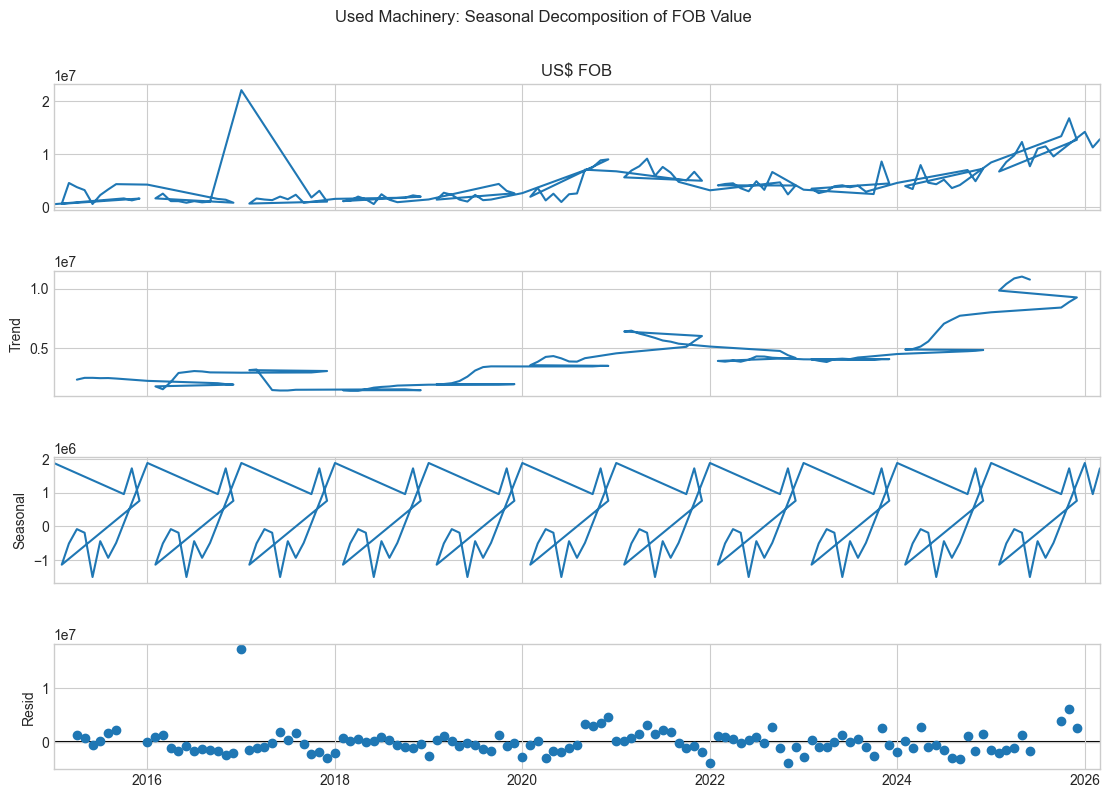

In [59]:
import statsmodels.api as sm
# not sure if i'll keep it
# Prepare a monthly time series of Total FOB value
ts_data = df_used_market.groupby(['ANO', 'MES'])['US$ FOB'].sum().reset_index()
# Create a proper datetime index
ts_data['Date'] = pd.to_datetime(ts_data['ANO'].astype(str) + '-' + ts_data['MES'].astype(str) + '-01')
ts_data.set_index('Date', inplace=True)

# Decompose the time series (Trend, Seasonality, Residuals)
decomposition = sm.tsa.seasonal_decompose(ts_data['US$ FOB'], model='additive', period=12)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Used Machinery: Seasonal Decomposition of FOB Value', y=1.02)
plt.show()

EDA FOR USED MACHINERY IMPORTERS

--- Top 20 Used Machinery Importers in Peru (2015-2024) ---


,,Total_Investment,Import_Frequency
RUC IMPORTADOR,IMPORTADOR,,
20538234754,MC MACHINERY & ELECTRONIC S.A.C,"51,384,672.41",859
20100028698,FERREYROS SOCIEDAD AN?NIMA,"38,112,338.58",181
0,Ley 29733 Protección de datos personales,"29,758,636.07",739
20170072465,SOCIEDAD MINERA CERRO VERDE S.A.A.,"23,375,503.01",4
20448664717,GH EQUIPMENT E.I.R.L.,"11,206,072.32",154
20517931536,KARLA EQUIPMENT S.A.C.,"10,370,888.17",203
20537984032,DESERT LOGISTIC SERVICES S.A.C.,"10,115,617.92",217
20487799484,MATERIALES Y SERVICIOS GENERALES FABRI E.I.R.L.,"9,857,809.33",122
20606433469,ECA BUSINESS E.I.R.L.,"7,905,411.62",159


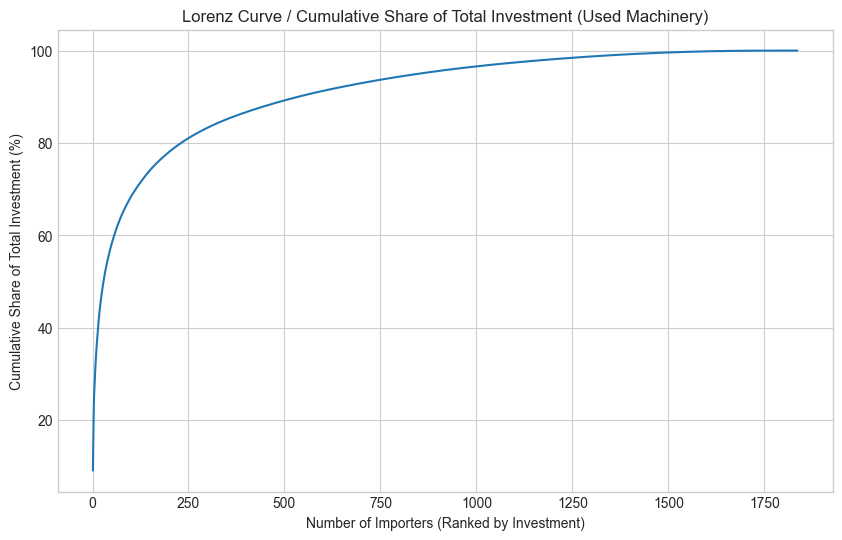

In [97]:
# Grouping by RUC to ensure we don't count the same guy twice
used_leaders = df_used_market.groupby(['RUC IMPORTADOR', 'IMPORTADOR']).agg({
    'US$ FOB': 'sum',
    'PARTIDA_CLEAN': 'count'
}).rename(columns={'US$ FOB': 'Total_Investment', 'PARTIDA_CLEAN': 'Import_Frequency'})

# Sort by money to see the biggest spenders
used_leaders = used_leaders.sort_values('Total_Investment', ascending=False)

print("--- Top 20 Used Machinery Importers in Peru (2015-2024) ---")
display(used_leaders.head(20))

# Calculate market share for Lorenz Curve
total_investment_used = used_leaders['Total_Investment'].sum()
used_leaders['Share'] = (used_leaders['Total_Investment'] / total_investment_used) * 100
used_leaders['Cumulative_Share'] = used_leaders['Share'].cumsum()

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(used_leaders) + 1), used_leaders['Cumulative_Share'])
plt.title('Lorenz Curve / Cumulative Share of Total Investment (Used Machinery)')
plt.xlabel('Number of Importers (Ranked by Investment)')
plt.ylabel('Cumulative Share of Total Investment (%)')
plt.grid(True)
plt.savefig('2_cum_share.png', dpi=150, bbox_inches='tight')
plt.show()

In [64]:
# let's check belgium
# Market share by Country of Origin
origin_shares = df_used_market.groupby('PAIS DE ORIGEN')['US$ FOB'].sum().sort_values(ascending=False)
origin_pct = (origin_shares / origin_shares.sum()) * 100

print("--- Market Share by Country of Origin (%) ---")
print(origin_pct.head(10))

# Check specifically for Belgium
belgium_share = origin_pct.get('BELGICA', 0)
print(f"\nBELGIUM CURRENT MARKET SHARE: {belgium_share:.2f}%")

--- Market Share by Country of Origin (%) ---
PAIS DE ORIGEN
ESTADOS UNIDOS   21.32
SUECIA           17.81
CHINA            14.73
COREA {SUR}       9.97
JAPON             8.43
BELGICA           7.49
BRASIL            6.01
ALEMANIA          3.10
FRANCIA           1.78
CANADA            1.55
Name: US$ FOB, dtype: float64

BELGIUM CURRENT MARKET SHARE: 7.49%


### Country of Origin — Market Share Evolution Over Time

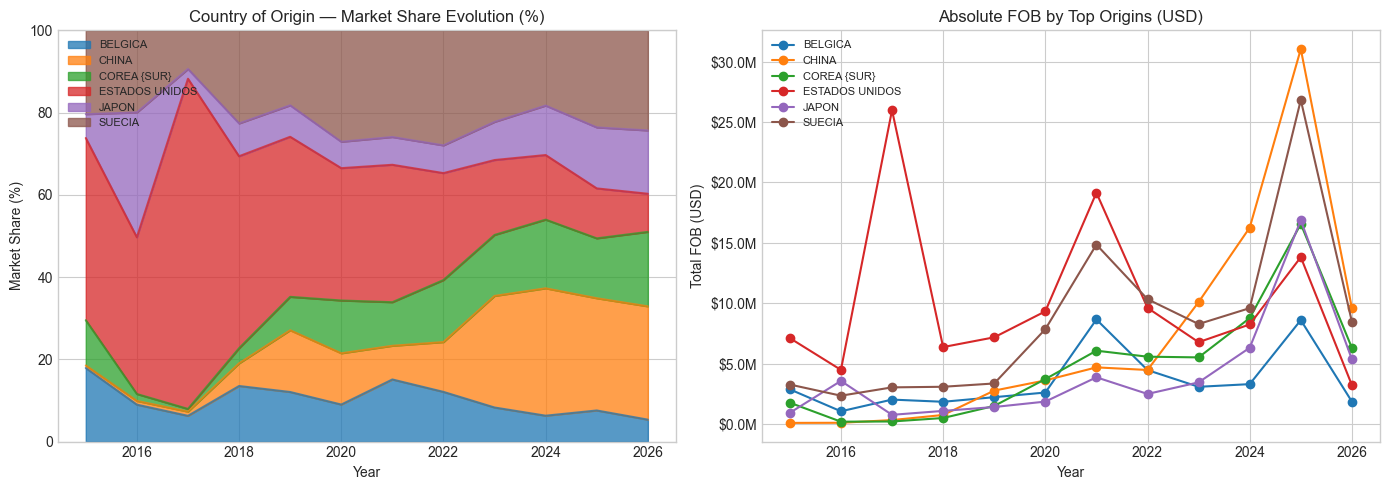


--- BELGICA (Belgium) FOB trend by year ---
          BELGICA
ANO              
2015 2,873,773.70
2016 1,056,977.40
2017 2,025,566.76
2018 1,844,655.50
2019 2,224,563.74
2020 2,609,963.95
2021 8,655,219.84
2022 4,468,431.37
2023 3,083,664.58
2024 3,304,649.01
2025 8,603,662.13
2026 1,858,457.02


In [101]:
# How has the market share of key supplier countries shifted year by year?
_top_origins = (
    df_used_market.groupby('PAIS DE ORIGEN')['US$ FOB']
    .sum().nlargest(6).index.tolist()
)

origin_time = (
    df_used_market[df_used_market['PAIS DE ORIGEN'].isin(_top_origins)]
    .groupby(['ANO', 'PAIS DE ORIGEN'])['US$ FOB']
    .sum()
    .unstack(fill_value=0)
)
origin_time.index = origin_time.index.astype(int)
origin_time_pct = origin_time.div(origin_time.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

origin_time_pct.plot(kind='area', stacked=True, ax=axes[0], alpha=0.75)
axes[0].set_title('Country of Origin — Market Share Evolution (%)')
axes[0].set_ylabel('Market Share (%)')
axes[0].set_xlabel('Year')
axes[0].legend(loc='upper left', fontsize=8)
axes[0].set_ylim(0, 100)

origin_time.plot(kind='line', marker='o', ax=axes[1])
axes[1].set_title('Absolute FOB by Top Origins (USD)')
axes[1].set_ylabel('Total FOB (USD)')
axes[1].set_xlabel('Year')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[1].legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('2_market_share_ev', dpi=150, bbox_inches='tight')
plt.show()

# Belgium trend explicitly
print("\n--- BELGICA (Belgium) FOB trend by year ---")
if 'BELGICA' in origin_time.columns:
    print(origin_time['BELGICA'].to_frame())
else:
    be_trend = (
        df_used_market[df_used_market['PAIS DE ORIGEN'] == 'BELGICA']
        .groupby('ANO')['US$ FOB'].sum()
    )
    print(be_trend if not be_trend.empty else "No Belgian entries found in used market.")


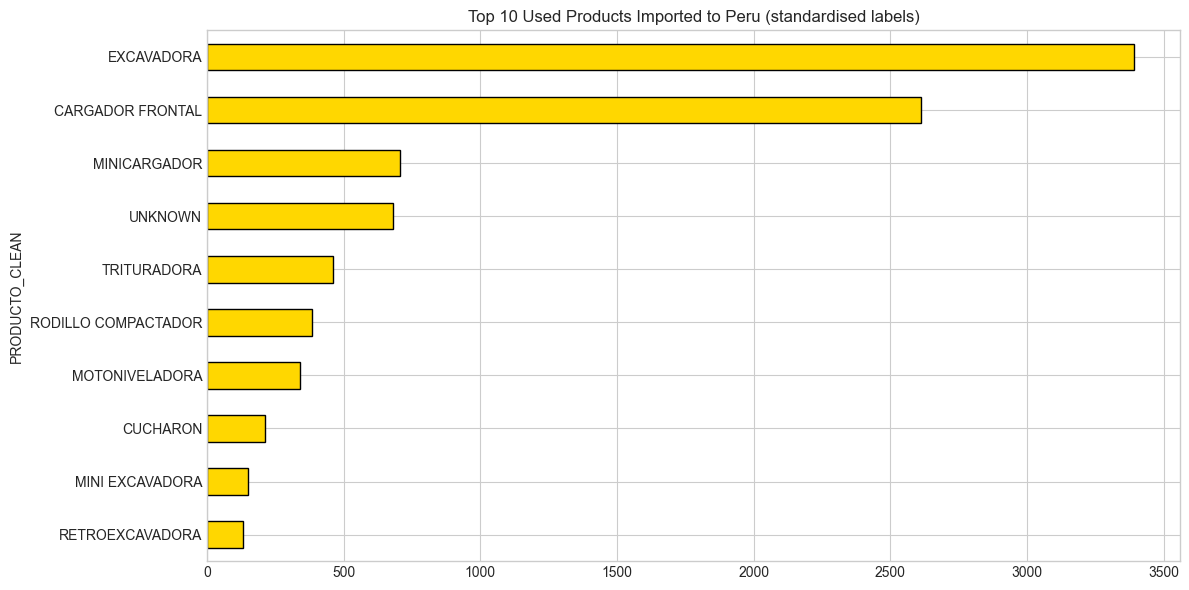

In [69]:
# Top products by volume — PRODUCTO_CLEAN (standardised in preprocessing)
top_products = df_used_market['PRODUCTO_CLEAN'].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_products.plot(kind='barh', color='gold', edgecolor='black')
plt.title('Top 10 Used Products Imported to Peru (standardised labels)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

STILL SOME DATA CLEANUP ON THE USED MACHINES DATASEt

In [72]:
# ── PRODUCTO_CLEAN breakdown — machines vs parts ──────────────────────────
_vc = df_used_market['PRODUCTO_CLEAN'].value_counts()
print(f'Unique PRODUCTO_CLEAN values: {_vc.shape[0]:,}')

print('\n--- Machine categories (IS_MACHINE=True) ---')
_mach_vc = (df_used_market[df_used_market['IS_MACHINE']]
            ['PRODUCTO_CLEAN'].value_counts())
print(_mach_vc.to_string())

print('\n--- Top 20 non-machine entries ---')
_parts_vc = (df_used_market[~df_used_market['IS_MACHINE']]
             ['PRODUCTO_CLEAN'].value_counts().head(20))
print(_parts_vc.to_string())

Unique PRODUCTO_CLEAN values: 527

--- Machine categories (IS_MACHINE=True) ---
PRODUCTO_CLEAN
EXCAVADORA             3389
CARGADOR FRONTAL       2612
MINICARGADOR            707
TRITURADORA             462
RODILLO COMPACTADOR     384
MOTONIVELADORA          341
MINI EXCAVADORA         150
RETROEXCAVADORA         133
PERFORADORA             118
MAQUINA DE ASFALTO      102
ZARANDA                  41
MONTACARGA               19
GRUA                      5
BULLDOZER                 5
REMOLCADOR                3
SCOOPTRAM                 2
CAMION                    1
VOLQUETE                  1

--- Top 20 non-machine entries ---
PRODUCTO_CLEAN
UNKNOWN                    682
CUCHARON                   212
MOLINO                      51
PUNTA                       35
N3                          29
EXCAVADOR                   19
MAQUINA DE PERFORACION       9
TRACTOR TIENDETUBOS          8
QUEBRANTADORA DE CONOS       8
PIN                          7
CAZO EXCAVADOR               7
PALA     

In [74]:
unknown_products = df_used_market[df_used_market['PRODUCTO_CLEAN'] == 'UNKNOWN']

print(f"Total 'UNKNOWN' entries in PRODUCTO_CLEAN: {len(unknown_products)}")
print("\n--- Sample of UNKNOWN products with relevant columns ---")
display(unknown_products[['IMPORTADOR', 'MARCA_CLEAN', 'MODELO', 'DESCRIPTION_MERGED', 'ANO', 'US$ FOB']].head(20))

print("\n--- Value counts for original 'PRODUCTO' within UNKNOWN_CLEAN entries ---")
display(unknown_products['PRODUCTO_CLEAN'].value_counts().head(50))

Total 'UNKNOWN' entries in PRODUCTO_CLEAN: 682

--- Sample of UNKNOWN products with relevant columns ---


,IMPORTADOR,MARCA_CLEAN,MODELO,DESCRIPTION_MERGED,ANO,US$ FOB
2791,EMPRESA DE TRANSPORTES ROMERO S.R.L.,CATERPILLAR,962H,A±O: 2010 // SERIE: CAT0962HCN4A02115 USADO - ...,2015,"123,480.00"
14823,MECANOTUBO PERU SAC,UNKNOWN,UNKNOWN,FRE 01 VIBROHINCADOR ICE 428 B 0108 CON 50 TU,2015,"36,097.74"
15452,BUSINESS TRADE IMPORT SAC,CATERPILLAR,UNKNOWN,USADO SERIE: CAT00246V5SZ08264,2015,"13,528.45"
16871,BUSINESS TRADE IMPORT SAC,UNKNOWN,UNKNOWN,USADO SERIE: 526017959,2015,"13,528.45"
44847,BANCO DE CREDITO DEL PERU,UNKNOWN,UNKNOWN,SERIAL No. 7470R USO MINERO DESARMADO. INC. AC...,2015,"657,527.26"
49118,PERFORACIONES E INGENIERIA PERU SOCIEDAD ANONI...,UNKNOWN,UNKNOWN,CON 350 PIES DE TUBERIA SERIE NO. 2V2734 PARA ...,2015,"57,673.03"
50661,GH EQUIPMENT E.I.R.L.,UNKNOWN,UNKNOWN,AÐO:2011 ENGINE ID: D13H*285646*A SERIAL: *VCE...,2015,"100,227.00"
84349,GAMARRA GIRALDEZ RAMIRO LEOPOLDO,UNKNOWN,UNKNOWN,"METAL USO COMERCIAL, USADO EN BULTO",2016,457.88
87533,GAMARRA GIRALDEZ RAMIRO LEOPOLDO,UNKNOWN,UNKNOWN,"METAL USO COMERCIAL, USADO EN BULTO",2016,457.88
106163,IMPORTADORA Y COMERCIALIZADORA YAMAMOTO E.I.R.L.,UNKNOWN,UNKNOWN,"MARCA: MIKASA MODELO: MT-62HS USO:USADO, MAL E...",2016,25.00



--- Value counts for original 'PRODUCTO' within UNKNOWN_CLEAN entries ---


PRODUCTO_CLEAN
UNKNOWN    682
Name: count, dtype: int64

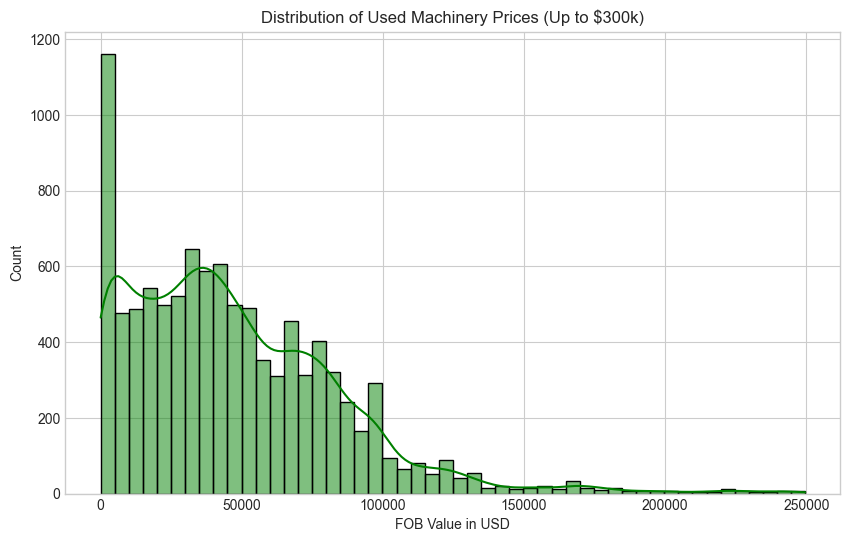

Median Used Machine Price: $41,256.00


In [76]:
plt.figure(figsize=(10, 6))
# Filtering out extreme outliers for a better visual
price_dist = df_used_market[df_used_market['US$ FOB'] < 250000]

sns.histplot(price_dist['US$ FOB'], bins=50, kde=True, color='green')
plt.title('Distribution of Used Machinery Prices (Up to $300k)')
plt.xlabel('FOB Value in USD')
plt.show()

print(f"Median Used Machine Price: ${df_used_market['US$ FOB'].median():,.2f}")

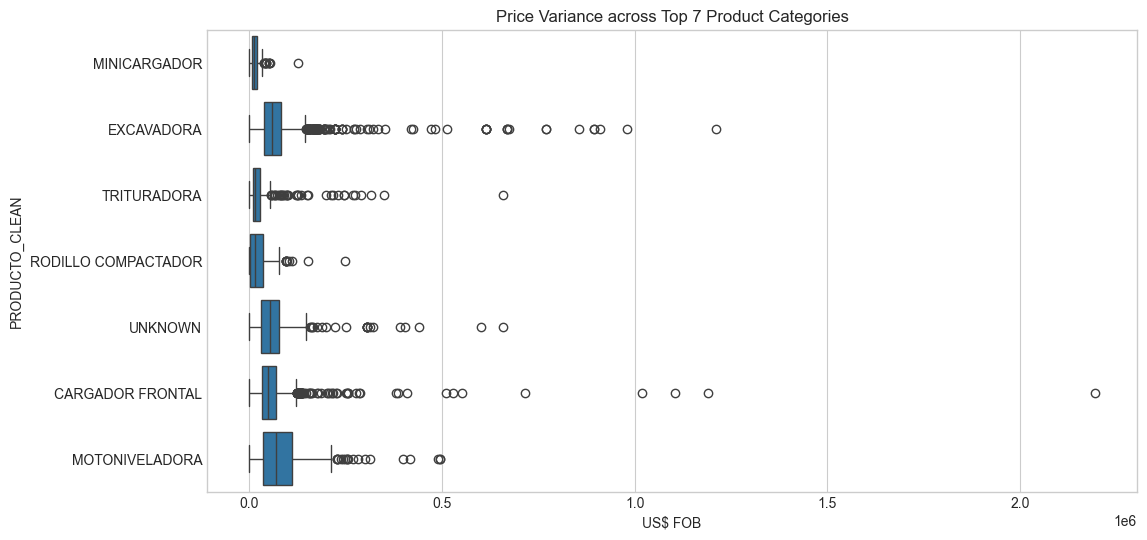


Average Price for Top 7 Product Categories:
- MOTONIVELADORA: $85,351.58
- EXCAVADORA: $66,695.89
- UNKNOWN: $60,852.95
- CARGADOR FRONTAL: $55,266.38
- TRITURADORA: $28,450.46
- RODILLO COMPACTADOR: $22,826.68
- MINICARGADOR: $13,695.95


In [78]:
# Focus on the Top 10 products to see if their 'Price DNA' is different
top_10_products = df_used_market['PRODUCTO_CLEAN'].value_counts().head(7).index.tolist()
df_top = df_used_market[df_used_market['PRODUCTO_CLEAN'].isin(top_10_products)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_top, x='US$ FOB', y='PRODUCTO_CLEAN')
plt.title("Price Variance across Top 7 Product Categories")

# Format x-axis to currency
#formatter = mticker.FormatStrFormatter('$%.0f')
#plt.gca().xaxis.set_major_formatter(formatter)
# You might still want a log scale for very wide ranges, but with a custom formatter.
# If the range is extremely wide, a log scale is still useful for visualization, but the user requested currency format.
# If a linear scale with currency format is preferred, just remove plt.xscale('log').
# For this case, I will remove the log scale for a clearer currency representation.
# plt.xscale('log') # Removed to allow currency formatting across the entire range
plt.show()

# Calculate and print the average price for each of the top 5 products
average_prices = df_top.groupby('PRODUCTO_CLEAN')['US$ FOB'].mean().sort_values(ascending=False)
print("\nAverage Price for Top 7 Product Categories:")
for product, avg_price in average_prices.items():
    print(f"- {product}: ${avg_price:,.2f}")

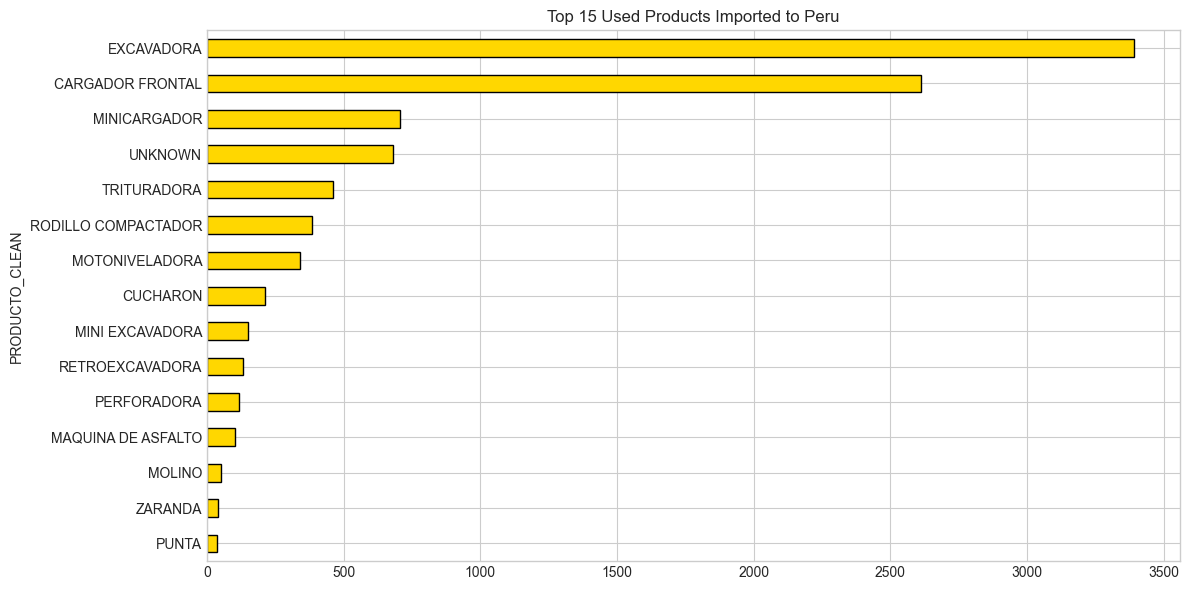

In [80]:
# Top 15 products — PRODUCTO_CLEAN already standardised in preprocessing
top_products = df_used_market['PRODUCTO_CLEAN'].value_counts().head(15)

plt.figure(figsize=(12, 6))
top_products.plot(kind='barh', color='gold', edgecolor='black')
plt.title('Top 15 Used Products Imported to Peru')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

df_used_market rows:    10,239
IS_MACHINE rows:        8,475
IS_MACHINE + FOB>=$10k: 7,539  <- df_units


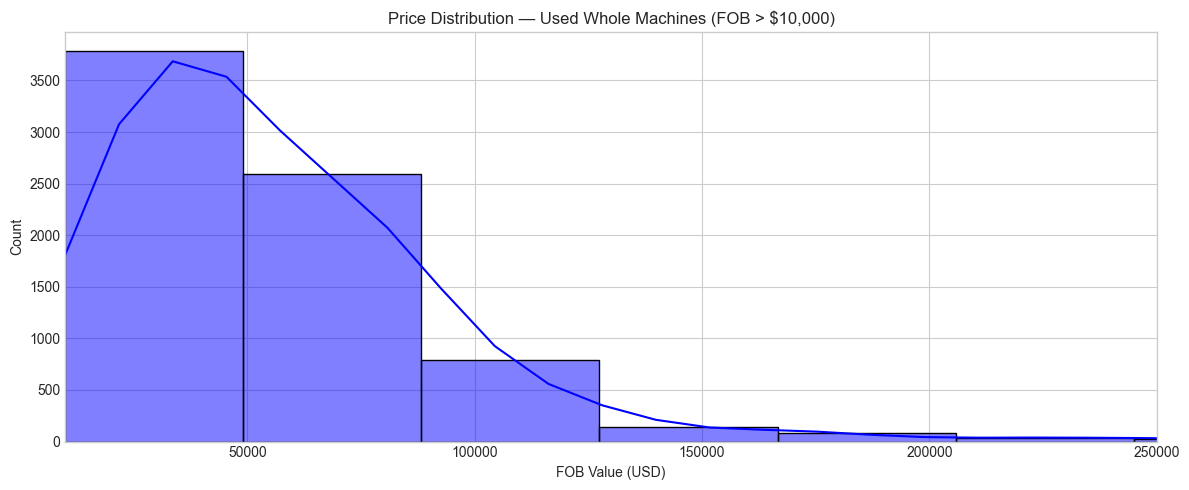

In [82]:
# df_units = used whole machines only (IS_MACHINE=True) with FOB >= $10k
# IS_MACHINE flag: set in preprocessing from 19 machine categories
# $10k floor: removes stray low-value line items (parts co-shipped)
price_floor = 10_000
df_units = df_used_market[
    df_used_market['IS_MACHINE'] &
    (df_used_market['US$ FOB'] >= price_floor)
].copy()

print(f'df_used_market rows:    {len(df_used_market):,}')
print(f'IS_MACHINE rows:        {df_used_market["IS_MACHINE"].sum():,}')
print(f'IS_MACHINE + FOB>=$10k: {len(df_units):,}  <- df_units')

plt.figure(figsize=(12, 5))
sns.histplot(df_units['US$ FOB'], bins=60, kde=True, color='blue')
plt.title(f'Price Distribution — Used Whole Machines (FOB > ${price_floor:,})')
plt.xlabel('FOB Value (USD)')
plt.xlim(price_floor, 250_000)
plt.tight_layout()
plt.show()

### Machine Type Mix — Which Categories Are Growing?

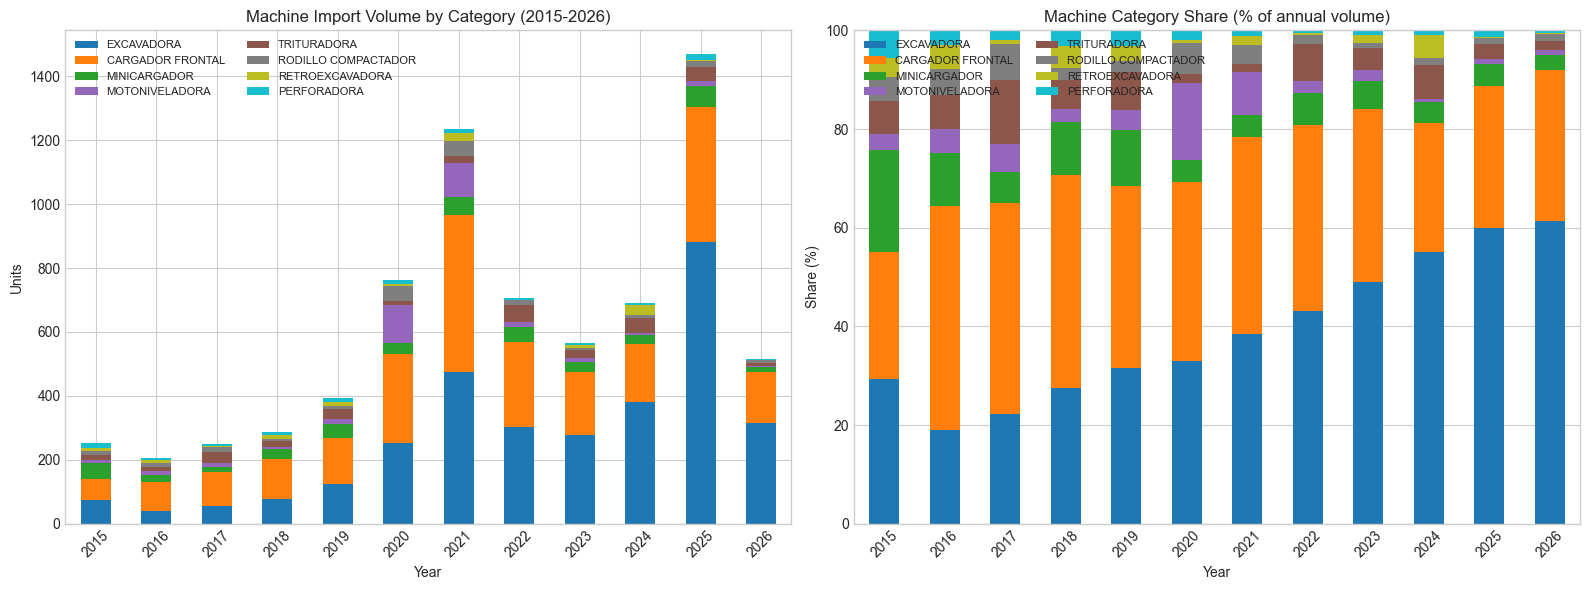

Cumulative volume by machine type:
PRODUCTO_CLEAN
EXCAVADORA             3257
CARGADOR FRONTAL       2527
MINICARGADOR            446
MOTONIVELADORA          334
TRITURADORA             322
RODILLO COMPACTADOR     210
RETROEXCAVADORA         121
PERFORADORA             112


In [85]:
# ── Machine Type Mix — volume by category, by year ────────────────────────
_mach = df_units.copy()
_mach['ANO'] = _mach['ANO'].astype(int)

_mach_vol = (
    _mach.groupby(['ANO', 'PRODUCTO_CLEAN'])
    .size().unstack(fill_value=0)
)
_top_cats = _mach_vol.sum().nlargest(8).index
_mach_vol = _mach_vol[_top_cats]
_mach_pct = _mach_vol.div(_mach_vol.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
_mach_vol.plot(kind='bar', stacked=True, ax=axes[0],
               colormap='tab10', edgecolor='none')
axes[0].set_title('Machine Import Volume by Category (2015-2026)')
axes[0].set_ylabel('Units'); axes[0].set_xlabel('Year')
axes[0].legend(loc='upper left', fontsize=8, ncol=2)
axes[0].tick_params(axis='x', rotation=45)

_mach_pct.plot(kind='bar', stacked=True, ax=axes[1],
               colormap='tab10', edgecolor='none')
axes[1].set_title('Machine Category Share (% of annual volume)')
axes[1].set_ylabel('Share (%)'); axes[1].set_xlabel('Year')
axes[1].set_ylim(0, 100)
axes[1].legend(loc='upper left', fontsize=8, ncol=2)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('machine_type_mix.png', dpi=150, bbox_inches='tight')
plt.show()

print('Cumulative volume by machine type:')
print(_mach_vol.sum().sort_values(ascending=False).to_string())

In [86]:
stats = df_units['US$ FOB'].describe(percentiles=[.25, .5, .75, .9])
print("--- Used Machinery Price Brackets ---")
print(f"Entry Level (25th percentile):  ${stats['25%']:,.2f}")
print(f"The 'Sweet Spot' (Median):       ${stats['50%']:,.2f}")
print(f"Premium Used (75th percentile): ${stats['75%']:,.2f}")
print(f"High-End / Mining (90th pct):   ${stats['90%']:,.2f}")

--- Used Machinery Price Brackets ---
Entry Level (25th percentile):  $30,726.82
The 'Sweet Spot' (Median):       $48,900.00
Premium Used (75th percentile): $75,031.44
High-End / Mining (90th pct):   $99,236.28


### Price Trend Over Time

--- Used Machinery Price Trend ---


,Median_Price,Avg_Price,Units
ANO,,,
2015,"$45,953","$74,101",255
2016,"$41,576","$67,855",215
2017,"$38,057","$53,841",251
2018,"$33,408","$51,242",296
2019,"$40,857","$57,188",398
2020,"$44,000","$58,839",783
2021,"$46,000","$55,706",1244
2022,"$49,736","$58,587",725
2023,"$49,419","$67,791",589


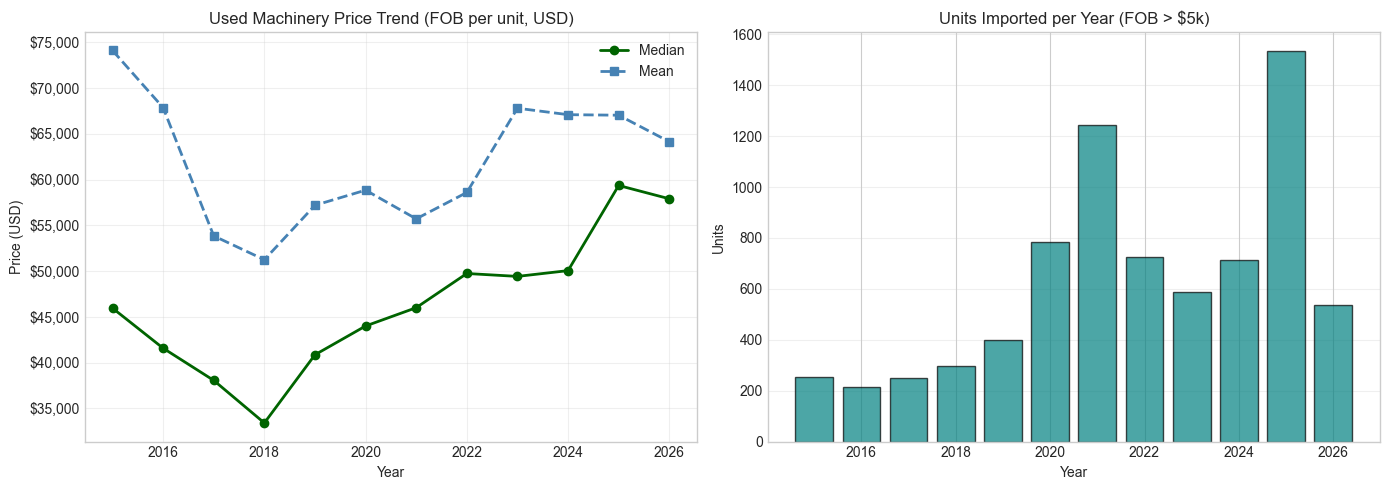

In [90]:
# How has the median price of a used machine evolved year by year?
price_trend = (
    df_units.groupby('ANO')['US$ FOB']
    .agg(['median', 'mean', 'count'])
    .rename(columns={'median': 'Median_Price', 'mean': 'Avg_Price', 'count': 'Units'})
)
price_trend.index = price_trend.index.astype(int)

print("--- Used Machinery Price Trend ---")
_fmt = pd.options.display.float_format
pd.options.display.float_format = '${:,.0f}'.format
display(price_trend)
pd.options.display.float_format = _fmt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(price_trend.index, price_trend['Median_Price'],
             marker='o', color='darkgreen', lw=2, label='Median')
axes[0].plot(price_trend.index, price_trend['Avg_Price'],
             marker='s', color='steelblue', lw=2, ls='--', label='Mean')
axes[0].set_title('Used Machinery Price Trend (FOB per unit, USD)')
axes[0].set_ylabel('Price (USD)')
axes[0].set_xlabel('Year')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(price_trend.index, price_trend['Units'],
            color='teal', edgecolor='black', alpha=0.7)
axes[1].set_title('Units Imported per Year (FOB > $5k)')
axes[1].set_ylabel('Units')
axes[1].set_xlabel('Year')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### New vs Used — Price Comparison by Product Category

--- New vs Used Median Price Comparison ---


,New_Median,Used_Median,Discount_Pct
PRODUCTO_CLEAN,,,
CARGADOR FRONTAL,"$169,300","$48,846",$71
EXCAVADORA,"$177,153","$60,000",$66
MOTONIVELADORA,"$196,429","$71,603",$64
MINICARGADOR,"$33,749","$17,459",$48
RODILLO COMPACTADOR,"$56,057","$33,332",$41
TRITURADORA,"$16,500","$22,327",$-35


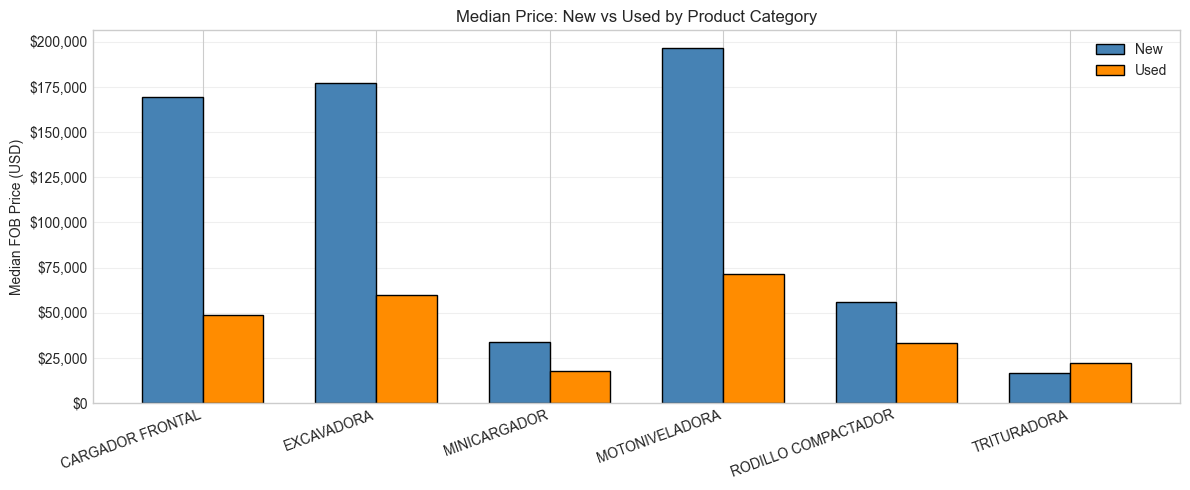

In [93]:
# Compare median prices for the same product categories across New and Used segments
_new_market = df_final_clean[
    df_final_clean['ESTADO DE MERCANCIA'].isin(['NUEVO', 'NUEVA', 'NUEVO DESARMADO', 'NUEVO SEMIARMADO'])
].copy()

_top_cats = (
    df_used_market[df_used_market['IS_MACHINE']]
    ['PRODUCTO_CLEAN'].value_counts().head(6).index.tolist()
)

_new_prices  = _new_market[_new_market['PRODUCTO_CLEAN'].isin(_top_cats)].groupby('PRODUCTO_CLEAN')['US$ FOB'].median().rename('New_Median')
_used_prices = df_units[df_units['PRODUCTO_CLEAN'].isin(_top_cats)].groupby('PRODUCTO_CLEAN')['US$ FOB'].median().rename('Used_Median')

price_comp = pd.concat([_new_prices, _used_prices], axis=1).dropna()
price_comp['Discount_Pct'] = (
    (price_comp['New_Median'] - price_comp['Used_Median']) / price_comp['New_Median']
) * 100

print("--- New vs Used Median Price Comparison ---")
_fmt2 = pd.options.display.float_format
pd.options.display.float_format = '${:,.0f}'.format
display(price_comp.sort_values('Discount_Pct', ascending=False))
pd.options.display.float_format = _fmt2

_x = np.arange(len(price_comp))
_w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(_x - _w/2, price_comp['New_Median'],  _w, label='New',  color='steelblue', edgecolor='black')
ax.bar(_x + _w/2, price_comp['Used_Median'], _w, label='Used', color='darkorange', edgecolor='black')
ax.set_xticks(_x)
ax.set_xticklabels(price_comp.index, rotation=20, ha='right')
ax.set_title('Median Price: New vs Used by Product Category')
ax.set_ylabel('Median FOB Price (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('2_median_price.png', dpi=150, bbox_inches='tight')
plt.show()


In [95]:
# See origin of machines between $30k and $100k (typical Belgian export range)
mid_market = df_units[(df_units['US$ FOB'] >= 30000) & (df_units['US$ FOB'] <= 100000)]
competitors = mid_market['PAIS DE ORIGEN'].value_counts().head(5)

print("--- Top Origins for Mid-Market Used Machinery ($30k - $100k) ---")
print(competitors)

--- Top Origins for Mid-Market Used Machinery ($30k - $100k) ---
PAIS DE ORIGEN
SUECIA            1183
ESTADOS UNIDOS     902
COREA {SUR}        764
BELGICA            504
CHINA              493
Name: count, dtype: int64


### Brand & Model Deep-Dive

In [168]:
print(df_units.columns)

Index(['DIA', 'MES', 'ANO', 'DUA', 'RUC IMPORTADOR', 'IMPORTADOR', 'DIRECCION',
       'DEPARTAMENTO DE IMPORTADOR', 'ESTADO', 'DISTRITO', 'PAIS DE ORIGEN',
       'PAIS DE ADQUISICION', 'PARTIDA ARANCELARIA', 'DESCRIPCION ARANCELARIA',
       'MERCANCIA', 'DESCRIPCION DE MERCANCIA 1', 'DESCRIPCION DE MERCANCIA 2',
       'DESCRIPCION DE MERCANCIA 3', 'PRODUCTO', 'MARCA', 'MODELO', 'US$ FOB',
       'US$ CIF', 'CANTIDAD', 'US$ CIF UNIT', 'ESTADO DE MERCANCIA',
       'PROBABLE EMBARCADOR', 'FECHA DE LLEGADA', 'US$ FOB UNIT',
       'FECHA DE EMBARQUE', 'PROVINCIA', 'REGION_UNIFIED', 'PARTIDA_CLEAN',
       'DESCRIPTION_MERGED', 'PRODUCTO_CLEAN', 'MARCA_CLEAN', 'IS_MACHINE',
       'IMPORTADOR_CLEAN'],
      dtype='str')


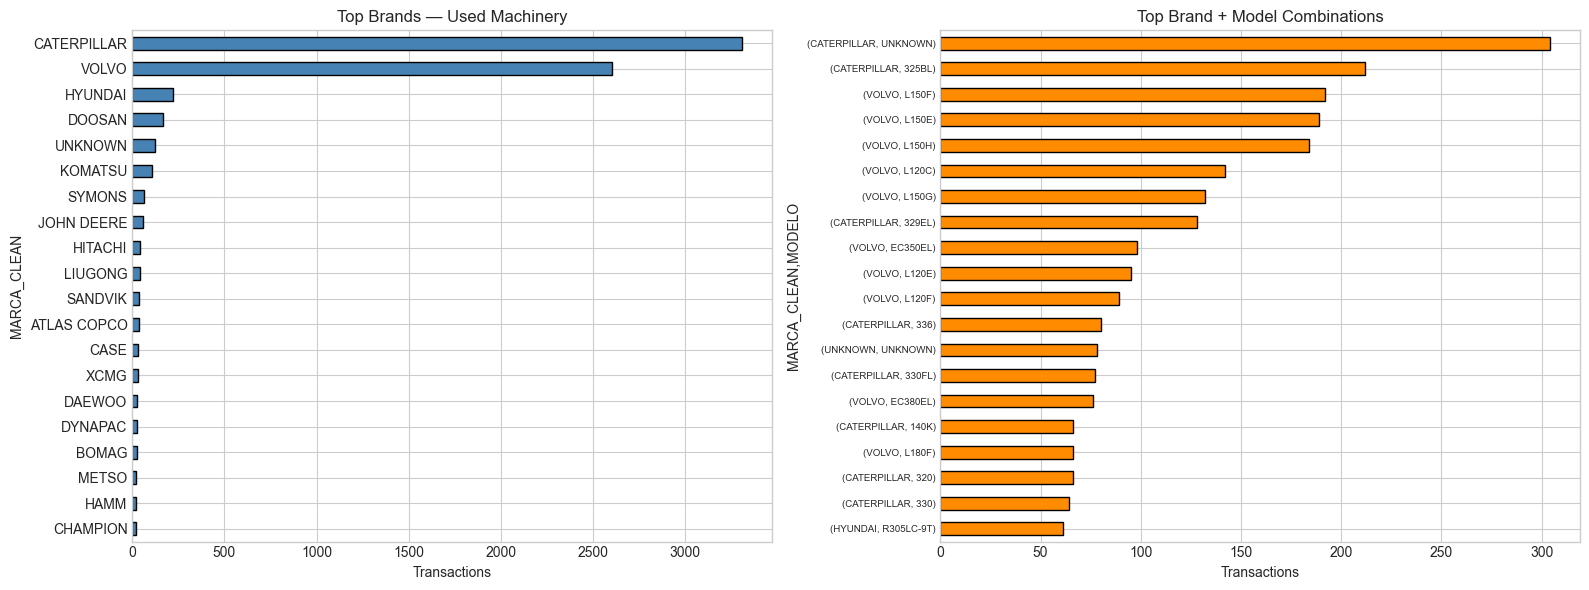


--- Brands with UNKNOWN model entries ---
MARCA_CLEAN  PRODUCTO_CLEAN     
CATERPILLAR  EXCAVADORA             102
             MINICARGADOR           101
             MOTONIVELADORA          62
UNKNOWN      TRITURADORA             22
             CARGADOR FRONTAL        21
CATERPILLAR  RETROEXCAVADORA         20
UNKNOWN      EXCAVADORA              18
HYUNDAI      EXCAVADORA              10
CATERPILLAR  CARGADOR FRONTAL         8
             MINI EXCAVADORA          7
UNKNOWN      PERFORADORA              6
SYMONS       TRITURADORA              5
UNKNOWN      MAQUINA DE ASFALTO       4
VOLVO        CARGADOR FRONTAL         2
DOOSAN       EXCAVADORA               2
CASE         RODILLO COMPACTADOR      2
PEGSON       TRITURADORA              2
METSO        TRITURADORA              2
UNKNOWN      MINI EXCAVADORA          2
             MOTONIVELADORA           2


In [170]:
# Top Brands and Models — using standardised MARCA_CLEAN
top_brands = df_units['MARCA_CLEAN'].value_counts().head(20)
top_models = (
    df_units.groupby(['MARCA_CLEAN', 'MODELO'])
    .size().sort_values(ascending=False).head(20)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_brands.sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Top Brands — Used Machinery')
axes[0].set_xlabel('Transactions')

top_models.sort_values().plot(
    kind='barh', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('Top Brand + Model Combinations')
axes[1].set_xlabel('Transactions')
axes[1].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.show()

unknown_models = df_units[df_units['MODELO'] == 'UNKNOWN']
print('\n--- Brands with UNKNOWN model entries ---')
print(unknown_models.groupby(['MARCA_CLEAN', 'PRODUCTO_CLEAN'])
      .size().sort_values(ascending=False).head(20).to_string())

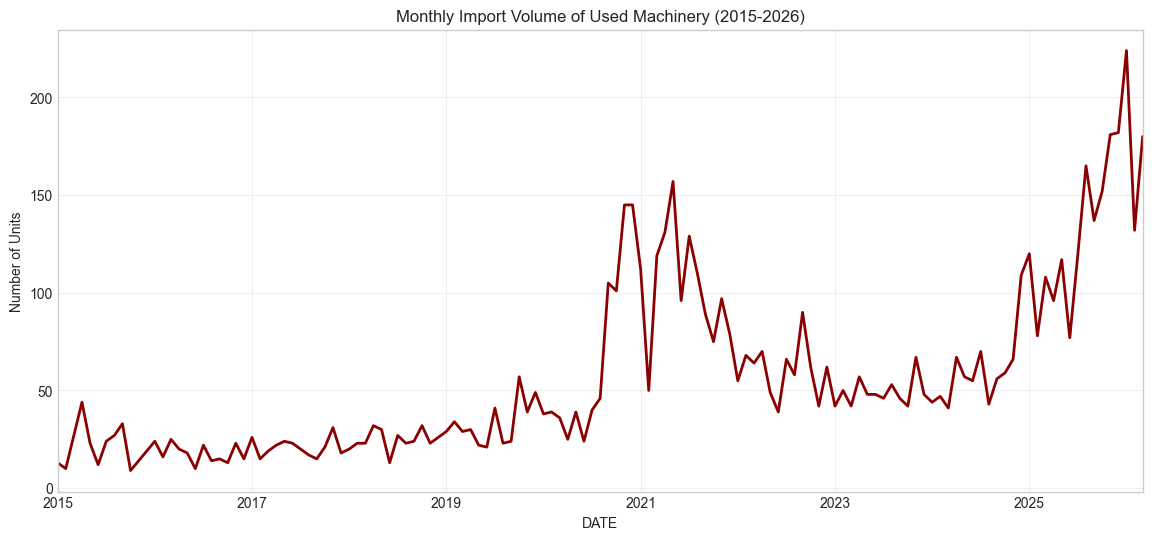

In [172]:
# Convert to datetime if you haven't yet
# Note: Combining AÑO and MES for a timeline
df_units['DATE'] = pd.to_datetime(df_units['ANO'].astype(str) + '-' + df_units['MES'].astype(str) + '-01')

temporal_trend = df_units.groupby('DATE').size()

plt.figure(figsize=(14, 6))
temporal_trend.plot(color='darkred', lw=2)
plt.title('Monthly Import Volume of Used Machinery (2015-2026)')
plt.ylabel('Number of Units')
plt.grid(True, alpha=0.3)
plt.show()

### LRFM & GRFM — Extended Customer Value Scoring

In [175]:
# ── LRFM & GRFM — Extended Customer Value Metrics ────────────────────────
# LRFM: Chang & Tsay (2004) — adds L (relationship duration) to RFM
# GRFM: Chang & Tsai (2011) — adds G (product variety breadth) instead of L
# Applied on df_units (IS_MACHINE, FOB >= $10k) per RUC IMPORTADOR.
from sklearn.preprocessing import MinMaxScaler

_df_l = df_units.copy()
_df_l['DATE'] = pd.to_datetime(
    _df_l['ANO'].astype(str) + '-' + _df_l['MES'].astype(str) + '-01'
)
_ref  = pd.to_datetime('2026-01-01')
_ncol = 'IMPORTADOR_CLEAN' if 'IMPORTADOR_CLEAN' in _df_l.columns else 'IMPORTADOR'

lrfm = _df_l.groupby('RUC IMPORTADOR').agg(
    IMPORTADOR = (_ncol,          'first'),
    First_Date = ('DATE',         'min'),
    Last_Date  = ('DATE',         'max'),
    Frequency  = ('PARTIDA_CLEAN','count'),
    Monetary   = ('US$ FOB',      'sum'),
    Variety    = ('PRODUCTO_CLEAN','nunique'),  # G dimension
)
lrfm['Length']  = ((lrfm['Last_Date'] - lrfm['First_Date']).dt.days / 30.44).clip(lower=0)
lrfm['Recency'] = ((_ref - lrfm['Last_Date']).dt.days / 30.44).clip(lower=0)

_sc   = MinMaxScaler()
_cols = ['Length','Recency','Frequency','Monetary','Variety']
_n    = pd.DataFrame(_sc.fit_transform(lrfm[_cols]),
                     index=lrfm.index, columns=[f'{c}_n' for c in _cols])
_n['Recency_n'] = 1 - _n['Recency_n']   # lower months ago = higher score

lrfm['LRFM_Score'] = (_n[['Length_n','Recency_n','Frequency_n','Monetary_n']].mean(axis=1))
lrfm['GRFM_Score'] = (_n[['Variety_n','Recency_n','Frequency_n','Monetary_n']].mean(axis=1))

_show = ['IMPORTADOR','Length','Recency','Frequency','Monetary','Variety','LRFM_Score','GRFM_Score']
print('--- Top 15 Clients by LRFM Score ---')
display(lrfm.sort_values('LRFM_Score', ascending=False)[_show].head(15))
print(f'\nClients scored:           {len(lrfm):,}')
print(f'Avg variety (G):          {lrfm["Variety"].mean():.1f} categories/importer')
print(f'Single-category buyers:   {(lrfm["Variety"]==1).sum():,}')

--- Top 15 Clients by LRFM Score ---


,IMPORTADOR,Length,Recency,Frequency,Monetary,Variety,LRFM_Score,GRFM_Score
RUC IMPORTADOR,,,,,,,,
20538234754,MC MACHINERY & ELECTRONIC S.A.C,132.00,0.00,717,"43,610,122.85",5,1.00,0.85
20100028698,FERREYROS SOCIEDAD AN?NIMA,96.98,6.04,169,"35,773,932.42",4,0.68,0.58
0,Ley 29733 Protección de datos personales,49.93,0.00,468,"23,790,265.06",11,0.64,0.80
20517931536,KARLA EQUIPMENT S.A.C.,129.99,0.00,189,"9,914,193.52",8,0.62,0.55
20537984032,DESERT LOGISTIC SERVICES S.A.C.,127.99,0.00,197,"9,606,640.38",5,0.61,0.47
20448664717,GH EQUIPMENT E.I.R.L.,128.06,0.00,142,"10,166,986.68",4,0.60,0.43
20501417646,TRANSPORTES GEMAR E.I.R.L.,132.92,0.00,134,"5,501,763.09",3,0.58,0.38
20518118103,TOTAL CAMIONETAS S.A.C.,125.03,0.00,138,"5,487,038.47",3,0.56,0.38
20490425668,KALICANTO PERU EIRL.,133.02,0.00,89,"5,378,581.24",7,0.56,0.46



Clients scored:           1,444
Avg variety (G):          1.4 categories/importer
Single-category buyers:   1,057


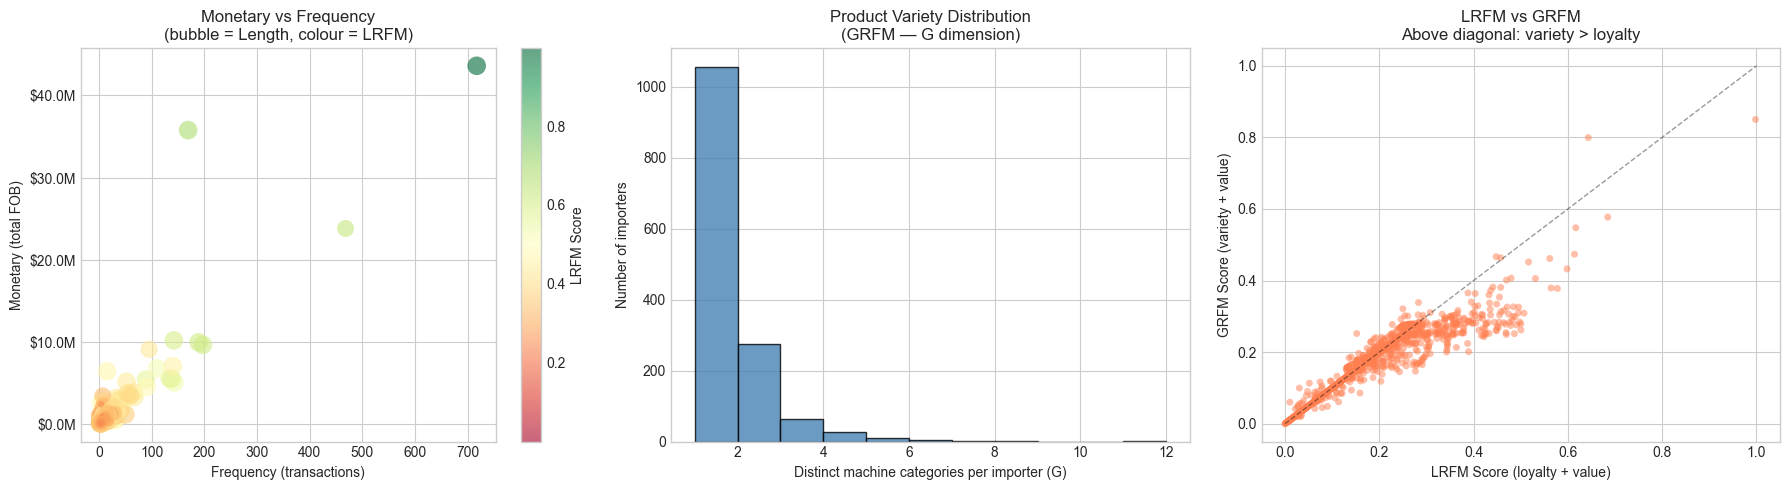

In [177]:
# ── LRFM / GRFM Visualisation ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Monetary vs Frequency bubble (size=Length, colour=LRFM)
sc = axes[0].scatter(
    lrfm['Frequency'], lrfm['Monetary'],
    c=lrfm['LRFM_Score'], cmap='RdYlGn',
    s=(lrfm['Length'].clip(1, 60) * 3).values,
    alpha=0.6, edgecolors='none'
)
plt.colorbar(sc, ax=axes[0], label='LRFM Score')
axes[0].set_xlabel('Frequency (transactions)')
axes[0].set_ylabel('Monetary (total FOB)')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f'${v/1e6:.1f}M'))
axes[0].set_title('Monetary vs Frequency\n(bubble = Length, colour = LRFM)')

# 2. Product variety — G dimension histogram
axes[1].hist(lrfm['Variety'],
             bins=range(1, min(int(lrfm['Variety'].max()) + 2, 20)),
             color='steelblue', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Distinct machine categories per importer (G)')
axes[1].set_ylabel('Number of importers')
axes[1].set_title('Product Variety Distribution\n(GRFM — G dimension)')

# 3. LRFM vs GRFM comparison
axes[2].scatter(lrfm['LRFM_Score'], lrfm['GRFM_Score'],
               alpha=0.5, color='coral', edgecolors='none', s=25)
axes[2].plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
axes[2].set_xlabel('LRFM Score (loyalty + value)')
axes[2].set_ylabel('GRFM Score (variety + value)')
axes[2].set_title('LRFM vs GRFM\nAbove diagonal: variety > loyalty')

plt.tight_layout()
plt.savefig('lrfm_grfm_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [179]:
# ── Handoff: save EDA outputs for the clustering notebook ──────────────────
import pickle, os

_handoff = {
    'df_units':       df_units,
    'df_used_market': df_used_market,
    'name_map':       name_map,
    'lrfm':           lrfm,          # LRFM/GRFM scores per RUC IMPORTADOR
}
_handoff_path = 'eda_handoff.pkl'
with open(_handoff_path, 'wb') as _f:
    pickle.dump(_handoff, _f)
print(f'Saved handoff to {os.path.abspath(_handoff_path)}')
print(f'  df_units:       {df_units.shape}')
print(f'  df_used_market: {df_used_market.shape}')
print(f'  lrfm:           {lrfm.shape}')
print(f'  name_map keys:  {len(name_map)}')

Saved handoff to /Users/fabriziocontreras/Desktop/KUL/Masters/Thesis/code/eda_handoff.pkl
  df_units:       (7539, 39)
  df_used_market: (10239, 38)
  lrfm:           (1444, 10)
  name_map keys:  4234
